In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler

D:\Aninst\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [3]:
x_train = x_train.reshape((60000, 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((10000, 28, 28, 1)).astype('float32') / 255

mean_image = np.mean(x_train, axis=0)
x_train -= mean_image
x_test -= mean_image


In [4]:
from sklearn.metrics import accuracy_score
from tensorflow import keras
from tensorflow.keras import layers, models
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), 
    layers.MaxPooling2D((2, 2)),                                         
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),                                          
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),                                          
    layers.Conv2D(64, (3, 3), padding = 'same', activation='relu'), 
    layers.Flatten(),                                                      
    layers.Dense(64, activation='relu'),                                   
    layers.Dense(10, activation='softmax')                                 
])

model.compile(optimizer = 'adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics = ['accuracy'])

model.fit(x_train, y_train, epochs = 10, verbose = 1, batch_size=64) 

test_loss, test_acc = model.evaluate(x_train, y_train, verbose=1)
y_pred = model.predict(x_train).argmax(axis = 1)
print('\nТестовая точность:', test_acc)

D:\Aninst\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


D:\Aninst\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7411 - loss: 0.7012
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8270 - loss: 0.4767
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8516 - loss: 0.4090
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8687 - loss: 0.3615
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8802 - loss: 0.3315
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8877 - loss: 0.3068
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8971 - loss: 0.2830
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9027 - loss: 0.2643
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9088 - loss: 0.2498
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9153 - loss: 0.2326
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9255 - loss: 0.2010
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step

Тестовая 

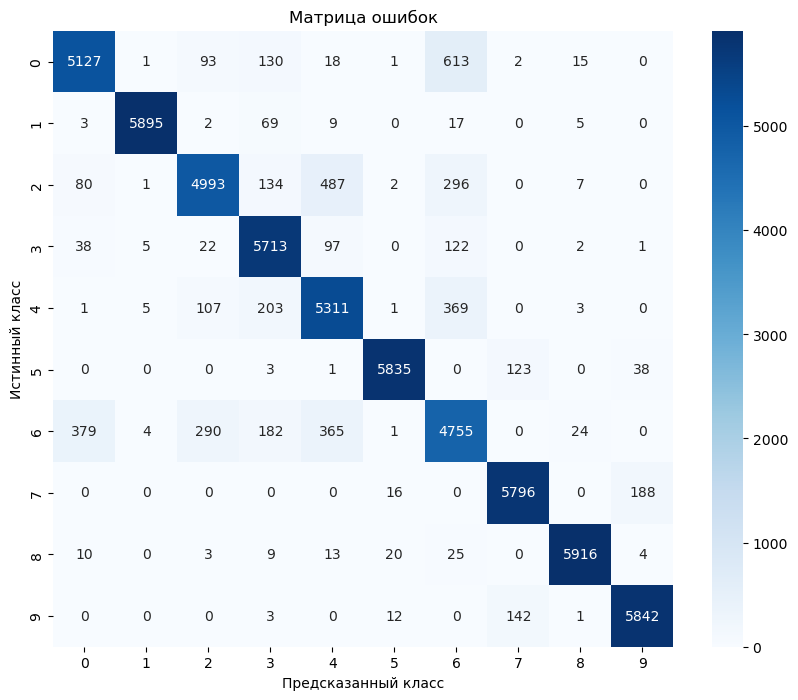

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_train, y_pred)
cm_df = pd.DataFrame(cm, index=range(10), columns=range(10))

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

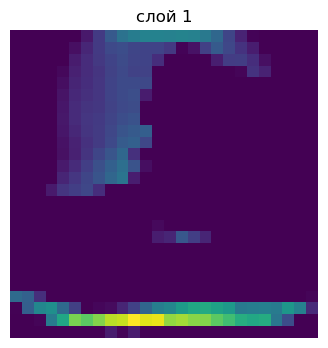

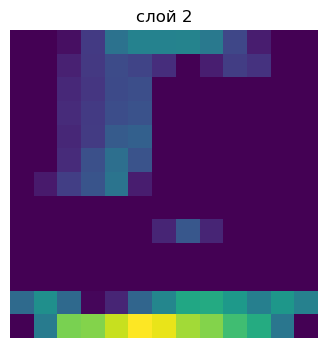

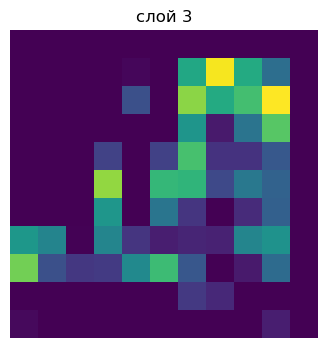

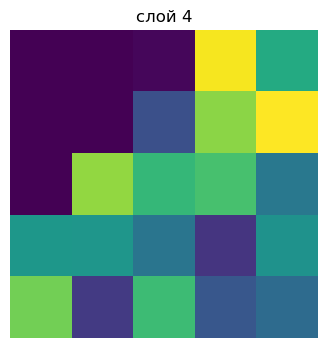

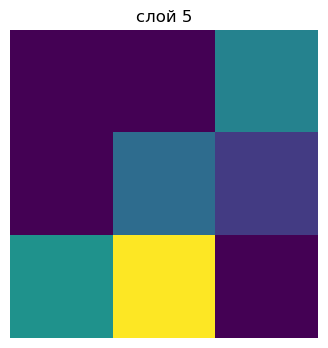

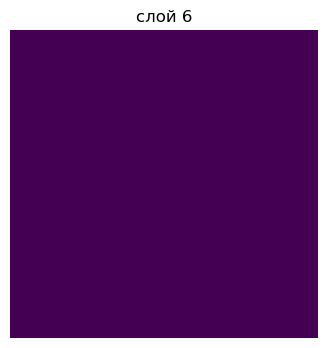

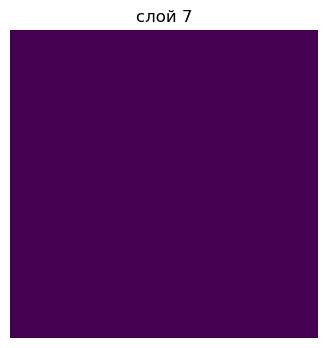

In [70]:
img = np.expand_dims(x_train[0], axis=0) #в x_train[0] входной формат (batch_size, height, width, channels)
x = img

for i, layer in enumerate(model.layers):
    x = layer(x)
    if len(x.shape) == 4:  #сверточный ли слой
        plt.figure(figsize=(4, 4))
        plt.imshow(x[0, :, :, 0], cmap='viridis')
        plt.title(f'слой {i+1}')
        plt.axis('off')
        plt.show()

In [3]:
x_train = x_train.reshape((60000, 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((10000, 28, 28, 1)).astype('float32') / 255

mean_image = np.mean(x_train, axis=0)
x_train -= mean_image
x_test -= mean_image

x_train = x_train.transpose(0, 3, 1, 2)
x_test = x_test.transpose(0, 3, 1, 2)

In [4]:
def create_pairs(x_train, x_test, y_train, y_test):
    tensor_train = []
    tensor_test = []
    for i in range(len(x_train)): 
        tensor_train.append([x_train[i], y_train[i]])
    for i in range(len(x_test)):   
        tensor_test.append([x_test[i], y_test[i]])
    return tensor_train, tensor_test

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

tensor_train, tensor_test = create_pairs(x_train, x_test, y_train, y_test)

batch_size = 64  
train_loader = torch.utils.data.DataLoader(dataset=tensor_train,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=tensor_test,
                                          batch_size=batch_size,
                                          shuffle=False)

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding='same')  
        self.relu1 = nn.ReLU() 
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.relu2 = nn.ReLU() 
        self.pool2 = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding='same')
        self.relu3 = nn.ReLU() 
        self.pool3 = nn.MaxPool2d(2)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding='same')
        self.relu4 = nn.ReLU()
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 3 * 3, 64) 
        self.relu5 = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)
        
    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.pool1(x) 
        x = self.relu2(self.conv2(x))
        x = self.pool2(x)  
        x = self.relu3(self.conv3(x))
        x = self.pool3(x)  
        x = self.relu4(self.conv4(x))
        
        x = self.flatten(x)
        x = self.relu5(self.fc1(x))
        x = self.fc2(x)  
        return x

model = CNNModel()
criterion = nn.CrossEntropyLoss()  
optimizer = optim.Adam(model.parameters())  

for epoch in range(10):  
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    train_acc = 100 * correct / total
    print(f'Эпоха {epoch+1}, loss: {running_loss/len(train_loader):.4f}, accuracy: {train_acc:.2f}%')

model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for batch_x, batch_y in test_loader:  
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

test_acc = 100 * correct / total
print(f'\nAccuracy: {test_acc:.2f}%')

model.eval()
with torch.no_grad():
    x_train_tensor = torch.FloatTensor(x_train)
    y_pred = model(x_train_tensor).argmax(dim=1).numpy()

Эпоха 1, loss: 0.5854, accuracy: 78.41%
Эпоха 2, loss: 0.3473, accuracy: 87.27%
Эпоха 3, loss: 0.2901, accuracy: 89.39%
Эпоха 4, loss: 0.2571, accuracy: 90.61%
Эпоха 5, loss: 0.2313, accuracy: 91.42%
Эпоха 6, loss: 0.2097, accuracy: 92.23%
Эпоха 7, loss: 0.1904, accuracy: 92.85%
Эпоха 8, loss: 0.1750, accuracy: 93.33%
Эпоха 9, loss: 0.1577, accuracy: 94.06%
Эпоха 10, loss: 0.1425, accuracy: 94.61%

Accuracy: 90.86%


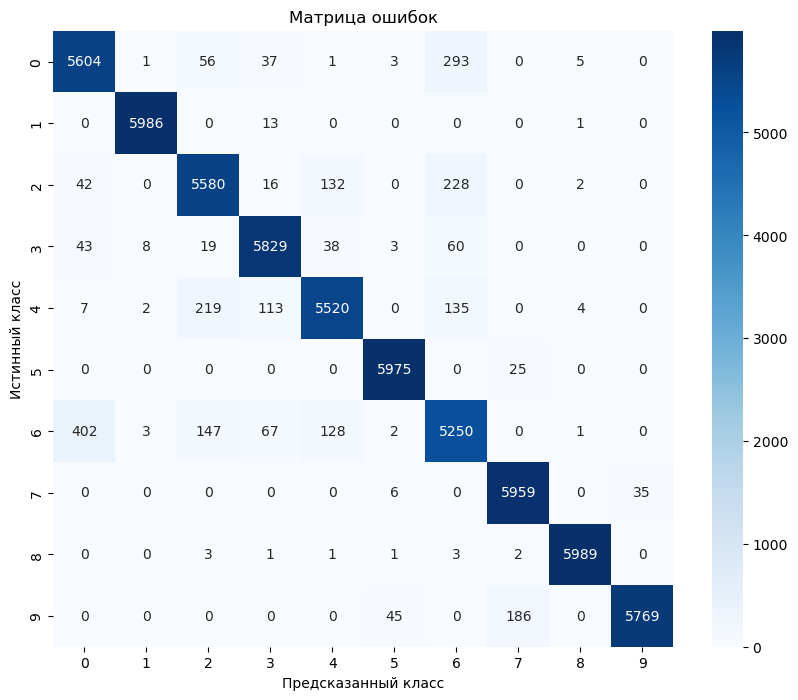

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_train, y_pred)
cm_df = pd.DataFrame(cm, index=range(10), columns=range(10))

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

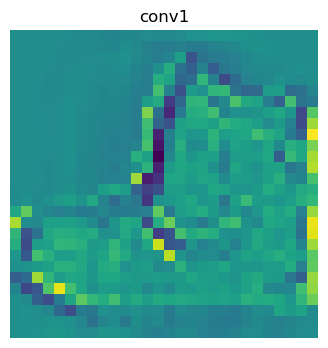

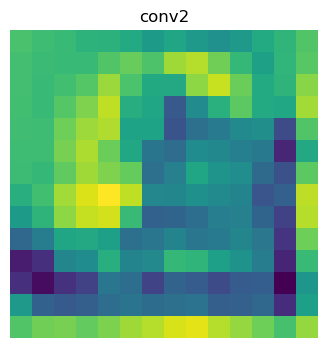

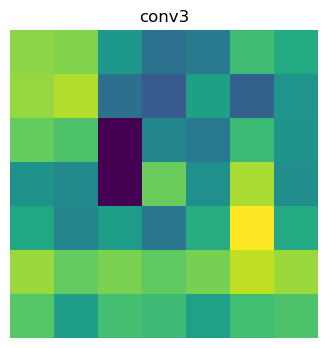

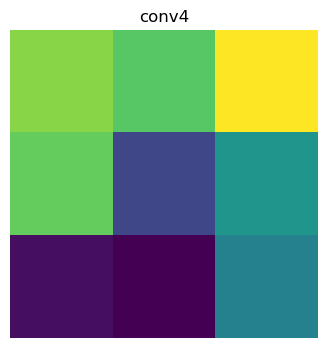

In [13]:
img = x_train[0:1]
x = torch.FloatTensor(img)

x = img_tensor = torch.FloatTensor(img)
for name, module in model.named_children():
    x = module(x)
    
    if 'conv' in name and len(x.shape) == 4:
        plt.figure(figsize=(4, 4))
        plt.imshow(x[0, 0].detach().numpy(), cmap='viridis')
        plt.title(f'{name}')
        plt.axis('off')
        plt.show()